Iqra Kaularikar | 221A060 | 14

UCB1: Selects actions based on both the estimated reward and uncertainity

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Iqra Kaularikar | 221A060 | 14
#Step1: To create multi armed bandit class
class MultiArmedBandit:
  def __init__(self, k):
    self.k = k
    self.q__true = np.random.normal(0, 1, k) #True rewards for each arm
    self.best_arm = np.argmax(self.q__true)

  def pull(self, arm):
    return np.random.normal(self.q__true[arm], 1) #Reward with some noise



*   Create k slot machines, each with a different hidden reward
*   List item



In [16]:
#Step2: To create agent class
class Agent:
  def __init__(self, bandit, strategy="epsilon_greedy", epsilon=0.1, c=2):
      self.bandit = bandit
      self.strategy = strategy
      self.epsilon = epsilon
      self.c = c
      self.k = bandit.k
      self.N = np.zeros(self.k) #No. of times each arm was pulled
      self.Q = np.zeros(self.k) #Estimated rewards

  def select_action(self, t):
    if self.strategy == "epsilon_greedy":
      if np.random.rand() < self.epsilon:
        return np.random.randint(self.k) #Random action
      return np.argmax(self.Q) #Exploit best-known action

    elif self.strategy == "ucb1":
      if 0 in self.N: #Ensures all arms tried atleast once
         return np.argmin(self.N)
      return np.argmax(self.Q + self.c * np.sqrt(np.log(t+1) / self.N))

  def update(self, action, reward):
    self.N[action] += 1
    self.Q[action] += (reward - self.Q[action]) / self.N[action] #Incremental mean update



* Implements Epsilon-Greedy, and UCB1 exploration agents
* Updates Q-values using the incremental mean method.





In [14]:
# Iqra Kaularikar | 221A060 | 14
#Step3:To create function to estimae average reward for each strategy
def run_strategy(k=10, steps=1000, runs=200, strategies=["epsilon_greedy", "ucb1"]):
    avg_rewards = {strategy: np.zeros(steps) for strategy in strategies}

    for strategy in strategies:
      for run in range(runs):
        bandit = MultiArmedBandit(k)
        agent = Agent(bandit, strategy=strategy)

        rewards = np.zeros(steps)
        for t in range(steps):
          action = agent.select_action(t)
          reward = bandit.pull(action)
          agent.update(action, reward)
          rewards[t] = reward

        avg_rewards[strategy] += rewards / runs

    return avg_rewards



* Runs multiple trials of each strategy.
*   List item



In [17]:
# Iqra Kaularikar | 221A060 | 14
#Step4: To run the exp. to estimate the avg. reward
strategies = ["epsilon_greedy", "ucb1"]
results = run_strategy()

In [18]:
results.keys()

dict_keys(['epsilon_greedy', 'ucb1'])

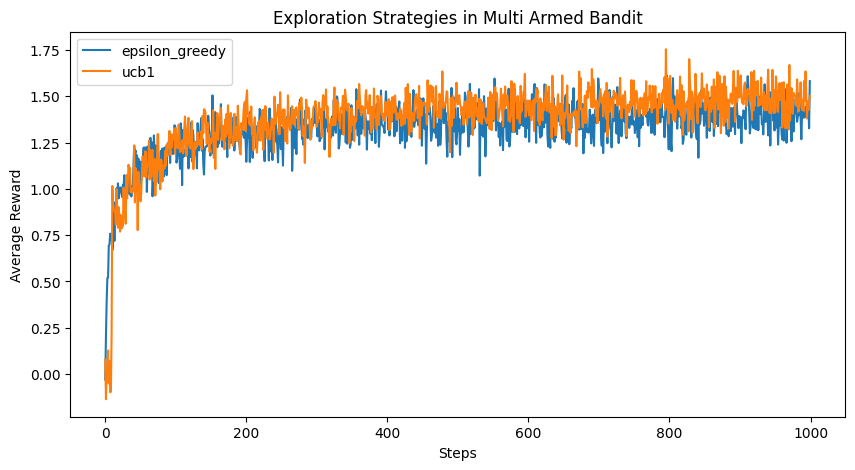

In [21]:
# Iqra Kaularikar | 221A060 | 14
#Plot the results
plt.figure(figsize=(10, 5))
for strategy, rewards in results.items():
    plt.plot(rewards, label=strategy)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Exploration Strategies in Multi Armed Bandit")
plt.legend()
plt.show()

-> Observations

Initial Phase (First 100 Steps)

*  Both strategies start with low rewards and improve over time.
*  UCB1 shows a faster initial learning rate, meaning it finds better arms more quickly.


Middle Phase (100 - 500 Steps)


*  UCB1 consistently outperforms Epsilon-Greedy with slightly higher rewards
*  Epsilon-Greedy fluctuates more, as it keeps exploring randomly with probability e.

Final Phase (500 - 1000 Steps)


*  UCB1 stabilizes at a slightly higher average reward.
*   Epsilon-Greedy keeps fluctuating due to its continued exploration.
*  UCB'S confidence bound exploration leads to better long - term exploration





-> Conclusion


*  For short duratios either of the algorithm can be used
*  But for long duration UCB1 must be used

